In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, uniform_filter

In [3]:
# Create a sample feature map (for example, a 5x5 feature map)
feature_map = np.array([[1, 2, 3, 0, 1],
                        [0, 1, 2, 3, 0],
                        [1, 0, 1, 2, 3],
                        [2, 1, 0, 1, 2],
                        [3, 2, 1, 0, 1]])
print("Original Feature Map:\n", feature_map)

Original Feature Map:
 [[1 2 3 0 1]
 [0 1 2 3 0]
 [1 0 1 2 3]
 [2 1 0 1 2]
 [3 2 1 0 1]]


In [9]:
# Max Pooling with a 2x2 window and stride of 2
max_pooled = maximum_filter(feature_map, size=2, mode='constant')

# Average Pooling with a 2x2 window and stride of 2
avg_pooled = uniform_filter(feature_map, size=2, mode='constant')

print("Max Pooled Feature Map:\n", max_pooled)
print("Average Pooled Feature Map:\n", avg_pooled)

Max Pooled Feature Map:
 [[1 2 3 3 1]
 [1 2 3 3 3]
 [1 1 2 3 3]
 [2 2 1 2 3]
 [3 3 2 1 2]]
Average Pooled Feature Map:
 [[0 0 1 0 0]
 [0 0 1 1 0]
 [0 0 0 1 1]
 [0 0 0 0 1]
 [1 1 0 0 0]]


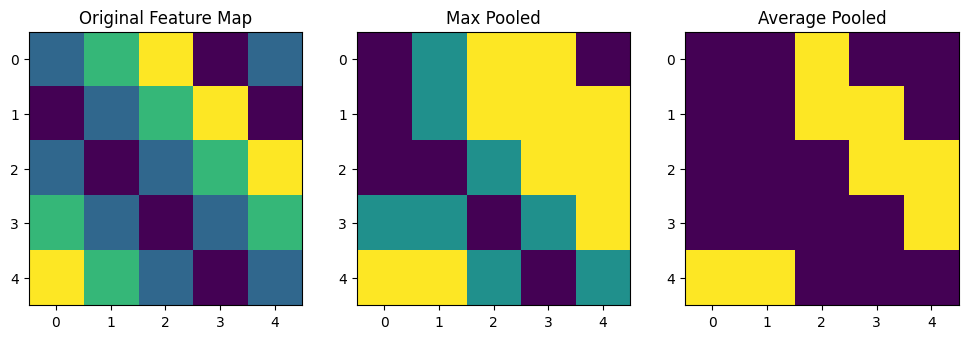

In [10]:
# plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original Feature Map")
plt.imshow(feature_map, cmap='viridis')
plt.subplot(1, 3, 2)
plt.title("Max Pooled")
plt.imshow(max_pooled, cmap='viridis')
plt.subplot(1, 3, 3)        
plt.title("Average Pooled")
plt.imshow(avg_pooled, cmap='viridis')
plt.show()


In [12]:
import tensorflow as tf

# Create a sample input tensor(1*4*4*1 for batch size, height, width, channels)
input_tensor = tf.constant(feature_map.reshape(1,5,5,1),dtype=tf.float32)

In [13]:
# Max pooling layer with a 2x2 window and stride of 2
max_pool_layer = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2)
max_pooled_tensor = max_pool_layer(input_tensor)
print("Max Pooled Tensor Shape:", max_pooled_tensor.shape)
print("Max Pooled Tensor:\n", max_pooled_tensor.numpy().squeeze())  

# Average pooling layer with a 2x2 window and stride of 2
avg_pool_layer = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2)
avg_pooled_tensor = avg_pool_layer(input_tensor)
print("Average Pooled Tensor Shape:", avg_pooled_tensor.shape)
print("Average Pooled Tensor:\n", avg_pooled_tensor.numpy().squeeze())

Max Pooled Tensor Shape: (1, 2, 2, 1)
Max Pooled Tensor:
 [[2. 3.]
 [2. 2.]]
Average Pooled Tensor Shape: (1, 2, 2, 1)
Average Pooled Tensor:
 [[1. 2.]
 [1. 1.]]
